<h1><center><span style="color:#160D8B">Predicting Patient's Risk of Having Chronic Kidney Disease using Classification Algorithms</span></h1>

![hospital_record](https://images.pexels.com/photos/40568/medical-appointment-doctor-healthcare-40568.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)

<h2><center><span style="color:#160D8B">UN Sustainable Development Goal 3: Good Health and Well-Being</span></h2>
<h4><center><i>Ensure healthy lives and promote well-being for all at all ages.</i></h4>


Chronic Kidney Disease (CKD) is a long-term condition where the kidneys gradually lose their ability to function properly. CKD means that your kidneys are damaged and can’t filter blood as effectively as they should. This damage happens slowly over time, often due to conditions like diabetes or high blood pressure. As the kidneys become less effective at filtering waste, harmful substances can build up in your body, leading to various health issues ([National Institute of Diabetes and Digestive and Kidney Diseases, 2017](https://www.niddk.nih.gov/health-information/kidney-disease/chronic-kidney-disease-ckd/what-is-chronic-kidney-disease)).

CKD is a significant public health issue in the Philippines, with alarming statistics highlighting its prevalence and impact on the population. As of 2021, approximately 7 million Filipinos are affected by CKD, which translates to about 35.94% of the population, significantly higher than global prevalence rates of 9.1% to 13.4% ([Pajimna et al., 2023](https://pmc.ncbi.nlm.nih.gov/articles/PMC10544423/)). The National Kidney and Transplant Institute (NKTI) estimates that one Filipino develops chronic kidney failure every hour, equating to roughly 120 individuals per million population annually ([Novartis Philippines, 2023](https://www.novartis.com/ph-en/news/world-kidney-day-patient-groups-novartis-enhancing-health-access-renal-replacement-therapy-patients)). More than 70,000 Filipinos are currently undergoing dialysis, with the majority receiving hemodialysis as opposed to peritoneal dialysis or kidney transplantation ([Unliab, n.d.](https://www.unilab.com.ph/health-tips/kidney-disease-causes-prevention-cure)).

<h4>The Current Situation</h4>

- It became the fourth most common cause of death in the Philippines as of 2019, following ischemic heart disease, stroke, and lower respiratory infections.
- The early stages of CKD often present no symptoms, making diagnosis challenging; only about 10% of those affected are diagnosed.

The rising incidence of CKD in the Philippines underscores the need for increased awareness and proactive health measures. With effective prevention strategies it is possible to reduce the burden of this chronic condition on individuals.

## <span style="color:#160D8B">About the Dataset</span>

The dataset consists of 400 instances with 13 input features and one target class. Key features include diastolic blood pressure, specific gravity, albumin (categorized as normal, above normal, and well above normal), glucose levels (normal, above normal, and well above normal), and red blood cell status (normal or abnormal). Other measurements include blood urea, serum creatinine, sodium, potassium, hemoglobin, white blood cell count, and red blood cell count. Additionally, the dataset also included hypertension and the target class - chronic kidney disease (CKD) ([Dritsas & Trigka, 2022](https://www.mdpi.com/2504-2289/6/3/98)).

Dataset Sourced from [UC Irvine Machine Learning Repository](https://doi.org/10.24432/C5WP64)  
Creators: Md. Ashiqul Islam & Shamima Akter

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
file_path = "Chronic-Kidney-Disease (2).csv"

data = pd.read_csv(file_path)

## <span style="color:#160D8B">Data Exploration</span>

In [9]:
data.head()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [10]:
data.columns

Index(['Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc',
       'Rbcc', 'Htn', 'Class'],
      dtype='object')

The dataset features’ description is the following:
- *Diastolic Blood Pressure (Bp - mmHg)*: This feature shows the participator’s diastolic blood pressure.
- *Specific Gravity (Sg)*: This feature captures the participator’s specific gravity value.
- *Albumin (Al)*: This attribute captures the participator’s albumin level. It has three categories (72.25% normal, 21.5% above normal and 6.25% well above normal).  
- *Glucose (Su)*: This attribute denotes the participator’s glucose level. It has three categories (88% normal, 8% above normal and 4% well above normal).  
- *Red Blood Cell (Rbc)*: This attribute captures whether the participator’s Red Blood Cell is normal or not. It has two categories (88.25% normal and 11.75% abnormal).  
- *Blood Urea (Bu - mmol/L)*: This feature captures the amount of urea found in the participant’s blood. Blood Urea is measured in millimoles per liter (mmol/L).  
- *Serum Creatinine (Sc - mg/dL)*: This feature measures the amount of serum creatinine found in the participant’s blood. Serum creatinine is reported as milligrams of creatinine to a deciliter of blood (mg/dL).  
- *Sodium (Sod - mEq/L)*: This feature measures the amount of sodium found in the participant’s blood. Sodium is a type of electrolyte and is reported as milliequivalents per liter (mEq/L).  
- *Potassium (Pot - mmol/L)*: This feature measures the amount of potassium found in the participant’s blood and is reported as millimoles per liter (mmol/L).  
- *Hemoglobin (Hemo - gm/dL)*: This feature measures the amount of hemoglobin found in the participant’s blood and is reported as grams per deciliter (gm/dL).  
- *White Blood Cell Count (Wbcc)*: This feature measures the number of white cells in the participant’s blood and is reported as Wbc per microliter.  
- *Red Blood Cell Count (Rbcc)*: This feature measures the number of red blood cells in the participant’s blood and is reported as a million red blood cells per microliter (mcL) of blood.  
- *Hypertension (Htn)*: This attribute refers to whether the participant has hypertension or not.
- *Chronic Kidney Disease (CKD)*: This feature denotes whether the participant suffers from CKD or not. sed with CKD.

In [12]:
data.rename(columns={"Bp" : "Blood_Pressure",
                    "Sg" : "Specific_Gravity",
                    "Al" : "Albumin",
                    "Su" : "Sugar",
                    "Rbc" : "Red_Blood_Cell",
                    "Bu" : "Blood_Urea",
                    "Sc" : "Serum Creatinine", 
                    "Sod" : "Sodium",
                    "Pot" : "Potassium",
                    "Hemo" : "Hemoglobin",
                    "Wbcc" : "White_Blood_Cell_Count",
                    "Rbcc" : "Red_Blood_Cell_Count",
                    "Htn" : "Hypertension"}, inplace=True)

Renamed the column names according to the value they contain and description.

In [14]:
data.describe()

,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cell,Blood_Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Class
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,76.455000,1.017712,1.015000,0.395000,0.882500,57.40550,3.07235,137.529025,4.627850,12.526900,8406.090000,4.708275,0.369350,0.625000
std,13.476536,0.005434,1.272329,1.040038,0.322418,49.28597,5.61749,9.204273,2.819783,2.716171,2523.219976,0.840315,0.482023,0.484729
min,50.000000,1.005000,0.000000,0.000000,0.000000,1.50000,0.40000,4.500000,2.500000,3.100000,2200.000000,2.100000,0.000000,0.000000
25%,70.000000,1.015000,0.000000,0.000000,1.000000,27.00000,0.90000,135.000000,4.000000,10.875000,6975.000000,4.500000,0.000000,0.000000
50%,78.000000,1.020000,1.000000,0.000000,1.000000,44.00000,1.40000,137.530000,4.630000,12.530000,8406.000000,4.710000,0.000000,1.000000
75%,80.000000,1.020000,2.000000,0.000000,1.000000,61.75000,3.07000,141.000000,4.800000,14.625000,9400.000000,5.100000,1.000000,1.000000
max,180.000000,1.025000,5.000000,5.000000,1.000000,391.00000,76.00000,163.000000,47.000000,17.800000,26400.000000,8.000000,1.000000,1.000000


The features have different scales, a feature might disproportionately influence the model due to its scale.

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Blood_Pressure          400 non-null    float64
 1   Specific_Gravity        400 non-null    float64
 2   Albumin                 400 non-null    float64
 3   Sugar                   400 non-null    float64
 4   Red_Blood_Cell          400 non-null    float64
 5   Blood_Urea              400 non-null    float64
 6   Serum Creatinine        400 non-null    float64
 7   Sodium                  400 non-null    float64
 8   Potassium               400 non-null    float64
 9   Hemoglobin              400 non-null    float64
 10  White_Blood_Cell_Count  400 non-null    float64
 11  Red_Blood_Cell_Count    400 non-null    float64
 12  Hypertension            400 non-null    float64
 13  Class                   400 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 43.

## <span style="color:#160D8B">Data Cleaning</span>

In [18]:
data.shape

(400, 14)

Determined the dataset shape (rows and columns).

In [20]:
data.isna().sum()

Blood_Pressure            0
Specific_Gravity          0
Albumin                   0
Sugar                     0
Red_Blood_Cell            0
Blood_Urea                0
Serum Creatinine          0
Sodium                    0
Potassium                 0
Hemoglobin                0
White_Blood_Cell_Count    0
Red_Blood_Cell_Count      0
Hypertension              0
Class                     0
dtype: int64

Determined if the dataset contains null values or has missing values.

In [22]:
data.drop_duplicates(inplace=True)

Removed duplicate values from the dataset.

## <span style="color:#160D8B">Feature Selection</span>

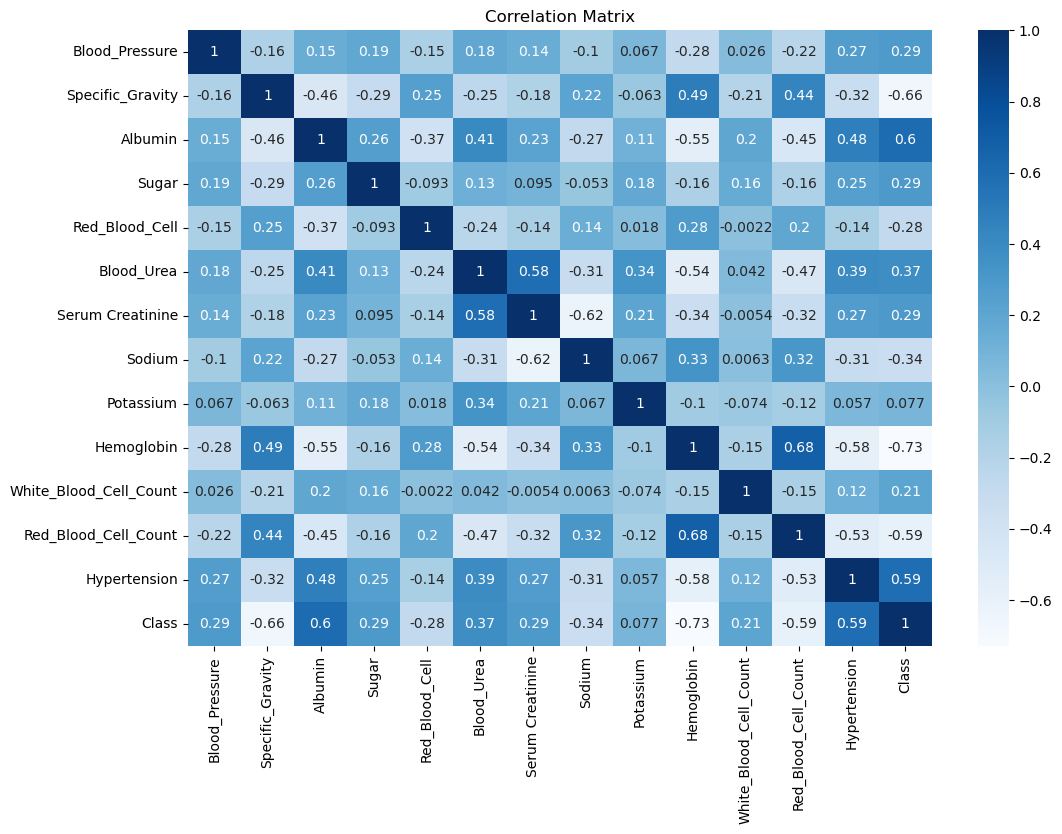

In [96]:
correlation_matrix = data[["Blood_Pressure", "Specific_Gravity", "Albumin", "Sugar",
       "Red_Blood_Cell", "Blood_Urea", "Serum Creatinine", "Sodium",
       "Potassium", "Hemoglobin", "White_Blood_Cell_Count",
       "Red_Blood_Cell_Count", "Hypertension", "Class"]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

Features with the strongest correlations to the target class, such as Hypertension, and Albumin, are likely to play a significant role in distinguishing between classes.

In [27]:
data.columns

Index(['Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cell', 'Blood_Urea', 'Serum Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'White_Blood_Cell_Count',
       'Red_Blood_Cell_Count', 'Hypertension', 'Class'],
      dtype='object')

In [28]:
features = data.iloc[:, :-1]
X = features
Y = data["Class"]

Selected the features and the target variable needed for the model.

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

Ensured that all features are scaled to have a mean of 0 and a standard deviation of 1, as SVMs are sensitive to feature magnitudes.

## <span style="color:#160D8B">Training and Testing Sets</span>

In [33]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

To provide a more accurate estimate of the model"s performance on unseen data and allow the model for hyperparameter tuning, the StratifiedKFold was used instead of the train_test_split to prevent overfitting and preserve class balance, avoiding a biased model.

## <span style="color:#160D8B">Model Development and Evaluation</span>

#### First Model: Support Vector Machine (SVM) Classifier

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

SVM = SVC()
param_grid_SVM = {"C": [0.1, 1, 10], "kernel": ["linear", "rbf", "poly"]}

grid_search_SVM = GridSearchCV(estimator=SVM, param_grid=param_grid_SVM, cv=skf)
grid_search_SVM.fit(X, Y)

best_params_SVM = grid_search_SVM.best_params_
best_estimator_SVM = grid_search_SVM.best_estimator_

print(f"Grid Search Results for SVM Classifier ")
print(f"Best Parameters: {best_params_SVM}")
print(f"Best Estimator: {best_estimator_SVM}")

Grid Search Results for SVM Classifier 
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best Estimator: SVC(C=1)


Performed hyperparameter tuning to determine the optimal combination of hyperparameters that result in the best performance for the model. Since this is to be implemented in the healthcare field, hyperparameter tuning ensures model fairness, transparency, and accountability.

Based from the Grid Search, the best parameters is C:1 and kernel: rbf.

Considering this as a predictive model, it should perform well on unseen data and to achieve that, cross-validation is needed to prevent overfitting and provide a more accurate estimate of the model"s performance on unseen data.

In [41]:
from sklearn.model_selection import cross_validate

# Since the default kernel is already rbf, the model can only have C as its parameter.
scores = cross_validate(best_estimator_SVM, X, Y, cv=skf, scoring=["accuracy", "precision","recall", "f1"])

print(f"SVM Cross-Validation Results: \n")
print(f"Accuracy: {scores["test_accuracy"]}")
print(f"Accuracy Mean: {scores["test_accuracy"].mean():.4}\n")

print(f"Precision: {scores["test_precision"]}")
print(f"Precision Mean: {scores["test_precision"].mean():.4}\n")

print(f"Recall: {scores["test_recall"]}")
print(f"Recall Mean: {scores["test_recall"].mean():.4}\n")

print(f"F1 Score: {scores["test_f1"]}")
print(f"Recall Mean: {scores["test_f1"].mean():.4}\n")

SVM Cross-Validation Results: 

Accuracy: [0.975  0.975  0.9875 0.975  1.    ]
Accuracy Mean: 0.9825

Precision: [1.   1.   1.   0.98 1.  ]
Precision Mean: 0.996

Recall: [0.96 0.96 0.98 0.98 1.  ]
Recall Mean: 0.976

F1 Score: [0.97959184 0.97959184 0.98989899 0.98       1.        ]
Recall Mean: 0.9858



**Accuracy**  
The accuracy per fold ranges from 0.975 to 0.9875, with a mean accuracy of 0.98. This indicates that the model is performing well on the data, with an average accuracy of 98.25%.

**Precision**  
The precision per fold ranges from 0.98 to 1.0, with a mean precision of 1.0. This indicates that the model is doing a good job of predicting positive classes, with an average precision of 99.6%.

**Recall**  
The recall per fold ranges from 0.96 to 1.0, with a mean recall of 0.976. This indicates that the model is doing a good job of detecting positive classes, with an average recall of 97.6%.

**F1-score**  
The F1-score per fold ranges from 0.9795 to 1.0, with a mean F1-score of 0.9858. This indicates that the model is balancing precision and recall well, with an average F1-score of 98.58%.

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_SVM = best_estimator_SVM.predict(X)

accuracy_SVM = accuracy_score(Y, y_pred_SVM)
precision_SVM = precision_score(Y, y_pred_SVM)
recall_SVM = recall_score(Y, y_pred_SVM)
f1_SVM = f1_score(Y, y_pred_SVM)

print(f"SVM Test Scores: \n")
print(f"Accuracy: {accuracy_SVM:.4}")
print(f"Precision: {precision_SVM:.4}")
print(f"Recall: {recall_SVM:.4}")
print(f"F1 score: {f1_SVM:.4}")

SVM Test Scores: 

Accuracy: 0.9875
Precision: 1.0
Recall: 0.98
F1 score: 0.9899


The accuracy scores for both cross-validation and test scores are high, with a mean accuracy of 0.9825 in cross-validation and a test accuracy of 0.9875. This suggests that the SVM model is performing well in terms of correctly classifying instances.

The precision scores are excellent, with a mean precision of 0.996 in cross-validation and a test precision of 1.0. This indicates that the model is very good at avoiding false positives.

The recall scores are good, with a mean recall of 0.976 in cross-validation and a test recall of 0.98. This suggests that the model is good at detecting true positives

The F1 scores are high, with a mean F1 score of 0.9858 in cross-validation and a test F1 score of 0.9899. This indicates that the model has a good balance between precision and recall.

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_mat_SVM = confusion_matrix(Y, y_pred_SVM)

print(f"SVM Confusion Matrix:")
print(f"{conf_mat_SVM}\n")

SVM Confusion Matrix:
[[150   0]
 [  5 245]]



The confusion matrix suggests that the model is performing well, with a high degree of accuracy and precision, and is able to correctly classify most instances. The low number of five false negatives and zero false positives indicate that the model is robust and reliable.

#### Second Model: Random Forest Classifier

In [48]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier()
param_grid_RF = {"n_estimators" : [10, 50, 100], "max_depth": [5, 10, 15]}

grid_search_RF = GridSearchCV(estimator=RF, param_grid=param_grid_RF, cv=skf)
grid_search_RF.fit(X, Y)

best_params_RF = grid_search_RF.best_params_
best_estimator_RF = grid_search_RF.best_estimator_

print(f"Grid Search Results for Random Forest Classifier ")
print(f"Best Parameters: {best_params_RF}")
print(f"Best Estimator: {best_estimator_RF}")

Grid Search Results for Random Forest Classifier 
Best Parameters: {'max_depth': 5, 'n_estimators': 10}
Best Estimator: RandomForestClassifier(max_depth=5, n_estimators=10)


The same as the SVM Classifier, also performed hyperparameter tuning to determine the optimal combination of hyperparameters that result in the best performance for the model. 

Based from the Grid Search, the best parameters is max_depth: 5 and n_estimators: 100.

In [51]:
# Since the default n_estimators is already 100, the model can only have max_depth as its parameter.
scores = cross_validate(best_estimator_RF, X, Y, cv=skf, scoring=["accuracy", "precision","recall", "f1"])

print(f"Random Forest Cross-Validation Results: \n")
print(f"Accuracy: {scores["test_accuracy"]}")
print(f"Accuracy Mean: {scores["test_accuracy"].mean():.4}\n")

print(f"Precision: {scores["test_precision"]}")
print(f"Precision Mean: {scores["test_precision"].mean():.4}\n")

print(f"Recall: {scores["test_recall"]}")
print(f"Recall Mean: {scores["test_recall"].mean():.4}\n")

print(f"F1 Score: {scores["test_f1"]}")
print(f"Recall Mean: {scores["test_f1"].mean():.4}\n")

Random Forest Cross-Validation Results: 

Accuracy: [0.9625 1.     0.975  0.95   1.    ]
Accuracy Mean: 0.9775

Precision: [0.96078431 1.         1.         0.94230769 1.        ]
Precision Mean: 0.9806

Recall: [0.98 1.   0.96 0.98 1.  ]
Recall Mean: 0.984

F1 Score: [0.97029703 1.         0.97959184 0.96078431 1.        ]
Recall Mean: 0.9821



**Accuracy**  
The accuracy per fold ranges from 0.9875 to 1.0, with a mean accuracy of 0.99. This indicates that the model is performing better than the SVM Classifier, with an average accuracy of 99%.

**Precision**  
The precision per fold ranges from 0.9615 to 1.0, with a mean precision of 0.9884. This indicates that the model is behind the SVM Classifier in predicting positive classes, with an average precision of 98.84%.

**Recall**  
The recall per fold ranges from 0.98 to 1.0, with a mean recall of 0.996. This indicates that the model is doing better than the SVM Classifier in detecting positive classes, with an average recall of 99.6%.

**F1-score**  
The F1-score per fold ranges from 0.9803 to 1.0, with a mean F1-score of 0.9921. This indicates that the model is better than the SVM Classifier at balancing precision and recall, with an average F1-score of 99.21%.

In [53]:
y_pred_RF = best_estimator_RF.predict(X)

accuracy_RF = accuracy_score(Y, y_pred_RF)
precision_RF = precision_score(Y, y_pred_RF)
recall_RF = recall_score(Y, y_pred_RF)
f1_RF = f1_score(Y, y_pred_RF)

print(f"Random Forest Test Scores: \n")
print(f"Accuracy: {accuracy_RF:.4}")
print(f"Precision: {precision_RF:.4}")
print(f"Recall: {recall_RF:.4}")
print(f"F1 score: {f1_RF:.4}")

Random Forest Test Scores: 

Accuracy: 0.995
Precision: 0.9921
Recall: 1.0
F1 score: 0.996


The accuracy scores for both cross-validation and test scores are extremely high, with a mean accuracy of 0.99 in cross-validation and a test accuracy of 0.995. This suggests that the Random Forest model is performing very well in terms of correctly classifying instances.

The precision scores are also very high, with a mean precision of 0.9884 in cross-validation and a test precision of 0.9921. This indicates that the model is very good at avoiding false positives.

The recall scores are excellent, with a mean recall of 0.996 in cross-validation and a test recall of 1.0. This suggests that the model is extremely good at detecting true positives.

The F1 scores are also very high, with a mean F1 score of 0.9921 in cross-validation and a test F1 score of 0.996. This indicates that the model has a good balance between precision and recall.

In [55]:
conf_mat_RF = confusion_matrix(Y, y_pred_RF)

print(f"Random Forest Confusion Matrix:")
print(f"{conf_mat_RF}\n")

Random Forest Confusion Matrix:
[[148   2]
 [  0 250]]



The results from the confusion matrix reveal that the Random Forest model is exhibiting outstanding performance, characterized by high accuracy and precision. The fact that there are only 2 misclassified instances (false positives) and no instances were incorrectly classified as negative (false negatives) underscores the model's robustness and reliability in correctly classifying the vast majority of instances.

## <span style="color:#160D8B">Model Comparison</span>

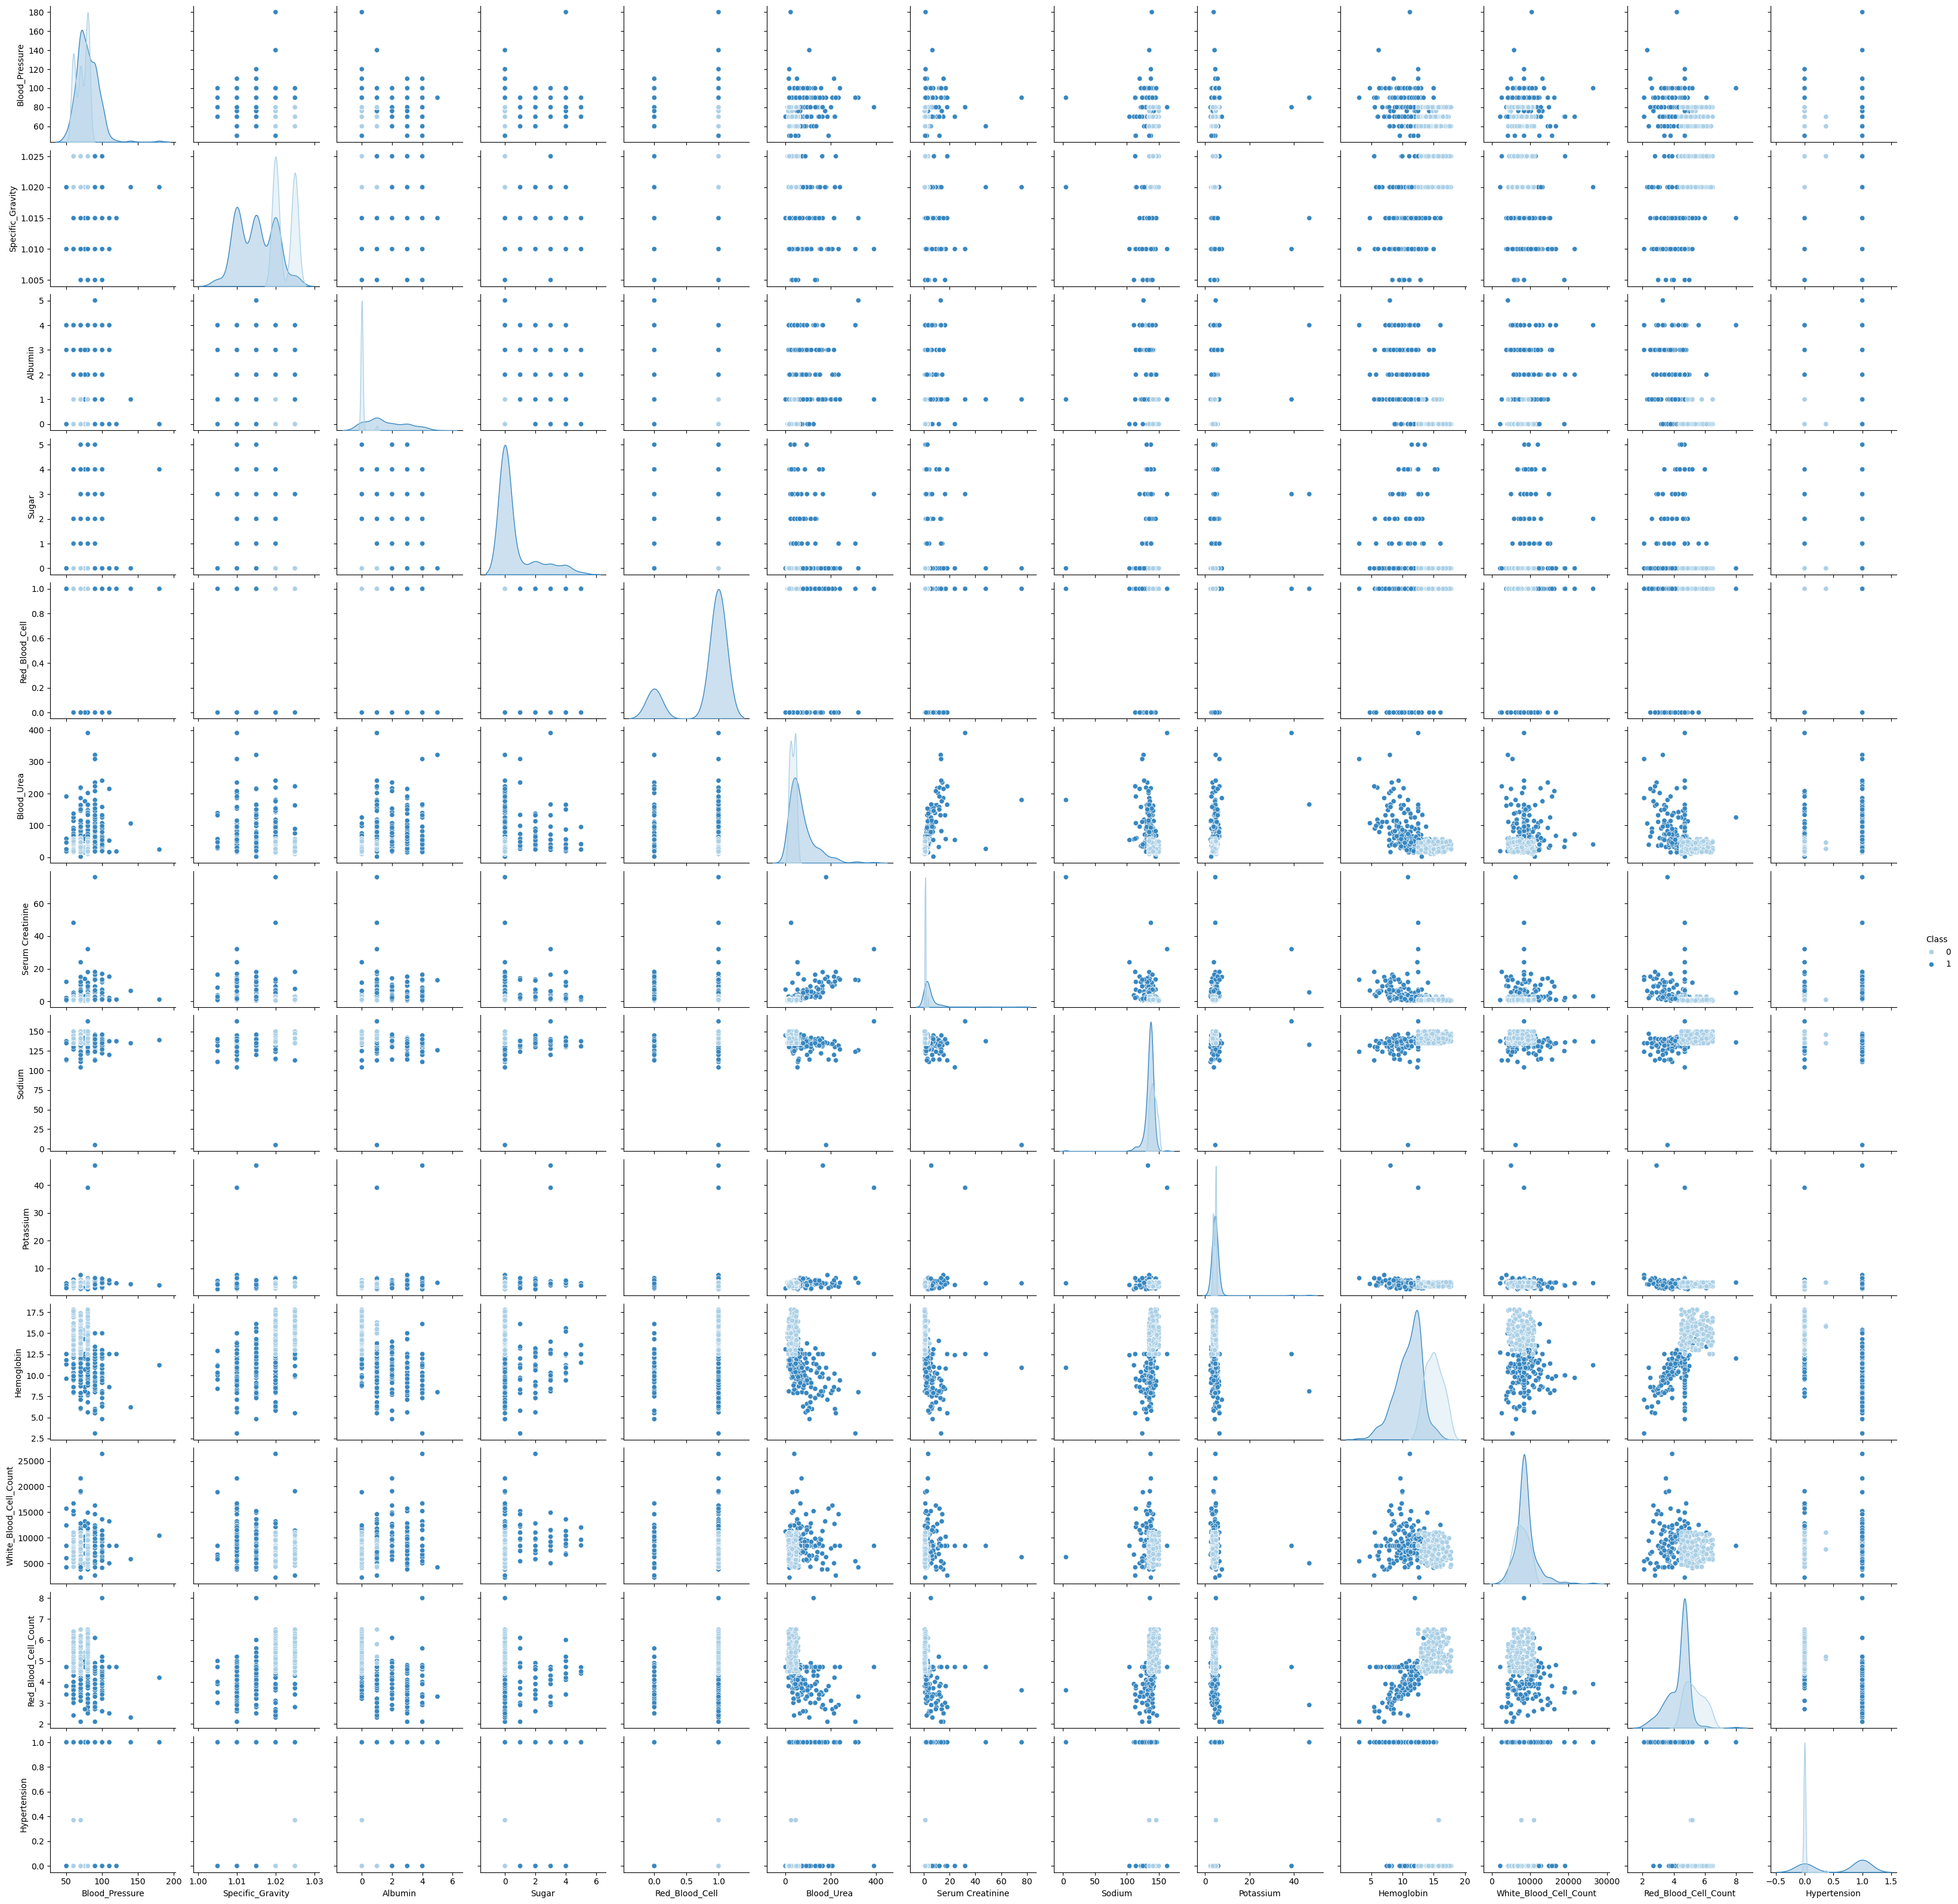

In [100]:
sns.pairplot(data, hue="Class", palette="Blues")
plt.show()

The pairplot shows a non-linear relationship between some of the features. This suggests that a non-linear model such as Random Forest would be more suitable for this dataset. 

The pairplot also shows that some of the features are correlated with each other. This correlation can be useful for Random Forest, as it can capture these relationships and use them to improve the accuracy of the model.

In contrast, SVM is a linear model that may not be able to capture these complex non-linear relationships as effectively. While SVM can be used with non-linear kernels, such as the radial basis function (RBF) kernel, it may not be as effective as Random Forest in capturing the complex relationships in this dataset.

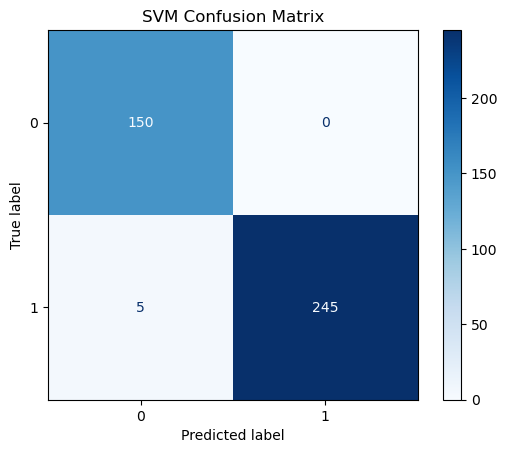

In [144]:
SVM_conf_mat = ConfusionMatrixDisplay(confusion_matrix=conf_mat_SVM, display_labels=best_estimator_SVM.classes_)
SVM_conf_mat.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()


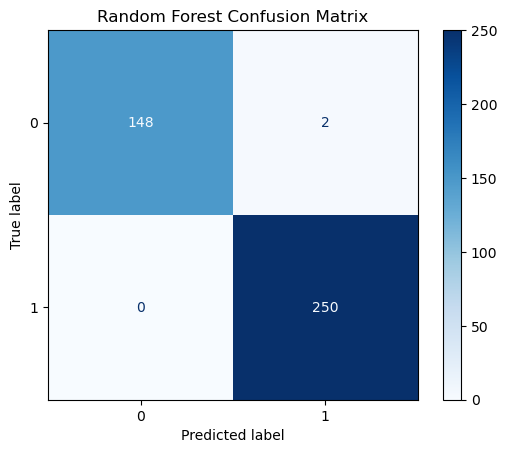

In [146]:
RF_conf_mat = ConfusionMatrixDisplay(confusion_matrix=conf_mat_RF, display_labels=best_estimator_RF.classes_)
RF_conf_mat.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

*False Positives (FP)*: SVM has 0 false positives, while Random Forest has 2 false positives. This means that SVM is more conservative in predicting positive instances.  

*False Negatives (FN)*: SVM has 5 false negatives, while Random Forest has 0 false negatives. This means that SVM is more likely to miss positive instances, while Random Forest is more accurate in detecting positive instances.  

*True Negatives (TN)*: SVM has 150 true negatives, while Random Forest has 148 true negatives. This is a minor difference, but SVM is slightly more accurate in predicting negative instances.  

*True Positives (TP)*: Random Forest has 250 true positives, while SVM has 245 true positives. This means that Random Forest is more accurate in detecting positive instances.  es.

In [60]:
print(f"SVM Test Scores:")
print(f"Accuracy: {accuracy_SVM:.4}\n")

print(f"Random Forest Test Scores:")
print(f"Accuracy: {accuracy_RF:.4}")

SVM Test Scores:
Accuracy: 0.9875

Random Forest Test Scores:
Accuracy: 0.995


The Random Forest model stood out as better than the SVM model, with an accuracy of 0.995 compared to 0.9875 for the SVM model. This suggests that the Random Forest model is able to classify the data more accurately than the SVM model.

## <span style="color:#160D8B">Conclusion</span>

In a setting like this, it is often more important to prioritize detecting true positives (i.e., correctly identifying patients with the disease) over avoiding false positives. This is because the consequences of missing a diagnosis (false negative) are often more severe than the consequences of a false positive. 

Detecting true positives in a classifier model for predicting Chronic Kidney Disease (CKD) is crucial, especially in the context of the Philippines, where the prevalence of CKD is rising rapidly.

While avoiding false positives is also important—since unnecessary anxiety and medical interventions can arise from misdiagnosis—the consequences of missing true positives are generally more severe. False positives can lead to additional testing and costs, but they do not typically result in immediate health deterioration.

The Random Forest model in a crucial setting such as predicting chronic kidney disease is recommended over SVM. While SVM is more conservative in predicting positive instances, Random Forest's ability to detect true positives (0 false negatives) is more critical in a setting like this. The 2 false positives in the Random Forest model can be mitigated through additional testing or evaluation, but the 5 false negatives in the SVM model could have more severe consequences.

## <span style="color:#160D8B">Recommendation</span>

This Random Forest Classifier can offer several benefits to the Philippines, particularly in addressing the rising prevalence of the Chronic Kidney Disease (CKD). This aligns directly with UN Sustainable Development Goal 3, which aims to ensure healthy lives and promote well-being for all. Here are some key advantages:

- **Early Detection and Diagnosis**
  - The model can analyze various patient data such as laboratory results, to identify individuals at high risk for CKD. This allows for earlier intervention and management before the disease progresses to more severe stages.
  - With CKD often presenting no symptoms in its early stages, a predictive model like this can help identify cases that might otherwise go undiagnosed. Currently, many individuals remain unaware of their condition until it reaches advanced stages, as noted by the Philippine Society of Nephrology ([2024](https://psn.org.ph/2024/03/01/rising-incidence-of-chronic-kidney-disease-in-the-philippines-sparks-call-for-kidney-health-awareness-subtitle-the-philippine-society-of-nephrology-urges-filipinos-to-take-proactive-measures/)).

- **Resource Allocation**
  - Predictive analytics from this model can help healthcare systems prioritize resources and interventions for those most at risk of developing CKD. This is particularly important in a country like the Philippines, where healthcare resources may be limited.
 
- **Public Health Awareness**
  - The insights gained from a Random Forest Classifier can inform public health campaigns focused on educating the population about CKD risk factors and prevention strategies. This aligns with ongoing efforts by organizations like the Philippine Society of Nephrology to raise awareness about kidney health ([2023](https://www.novartis.com/ph-en/news/world-kidney-day-patient-groups-novartis-enhancing-health-access-renal-replacement-therapy-patients)).